# Phần 1: Tiền xử lý dữ liệu (Data Preprocessing)

## 1.1. Tải dữ liệu

In [1]:
# Import thư viện
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Thiết lập đường dẫn thư mục chứa dữ liệu đầu vào
DATA_DIR = 'dataset/'

> `Sales`: dữ liệu doanh thu (huấn luyện)

In [3]:
df_sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date'])
df_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[us]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 90.0 KB


> `Products`: Danh mục sản phẩm

In [4]:
df_products = pd.read_csv(DATA_DIR + 'products.csv')
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   str    
 2   category      2412 non-null   str    
 3   segment       2412 non-null   str    
 4   size          2412 non-null   str    
 5   color         2412 non-null   str    
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 150.9 KB


> `Customers`: Thông tin khách hàng

In [5]:
df_customers = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date'])
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   customer_id          121930 non-null  int64         
 1   zip                  121930 non-null  int64         
 2   city                 121930 non-null  str           
 3   signup_date          121930 non-null  datetime64[us]
 4   gender               121930 non-null  str           
 5   age_group            121930 non-null  str           
 6   acquisition_channel  121930 non-null  str           
dtypes: datetime64[us](1), int64(2), str(4)
memory usage: 6.5 MB


> `Promotions`: Các chiến dịch khuyến mãi

In [6]:
df_promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date','end_date'])
df_promotions.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   promo_id             50 non-null     str           
 1   promo_name           50 non-null     str           
 2   promo_type           50 non-null     str           
 3   discount_value       50 non-null     float64       
 4   start_date           50 non-null     datetime64[us]
 5   end_date             50 non-null     datetime64[us]
 6   applicable_category  10 non-null     str           
 7   promo_channel        50 non-null     str           
 8   stackable_flag       50 non-null     int64         
 9   min_order_value      50 non-null     int64         
dtypes: datetime64[us](2), float64(1), int64(2), str(5)
memory usage: 4.0 KB


> `Geography`: Danh sách mã bưu chính các vùng

In [7]:
df_geography = pd.read_csv(DATA_DIR + 'geography.csv')
df_geography.info()

<class 'pandas.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   zip       39948 non-null  int64
 1   city      39948 non-null  str  
 2   region    39948 non-null  str  
 3   district  39948 non-null  str  
dtypes: int64(1), str(3)
memory usage: 1.2 MB


> `Orders`: thông tin đơn hàng

In [8]:
df_orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date'])
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  int64         
 1   order_date      646945 non-null  datetime64[us]
 2   customer_id     646945 non-null  int64         
 3   zip             646945 non-null  int64         
 4   order_status    646945 non-null  str           
 5   payment_method  646945 non-null  str           
 6   device_type     646945 non-null  str           
 7   order_source    646945 non-null  str           
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 39.5 MB


> `Order Items`: Chi tiết từng dòng sản phẩm trong đơn

In [9]:
df_order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  str    
 6   promo_id_2       206 non-null     str    
dtypes: float64(2), int64(3), str(2)
memory usage: 38.2 MB


> `Payments`: Thông tin thanh toán (tương ứng 1:1 với đơn hàng)

In [10]:
df_payments = pd.read_csv(DATA_DIR + 'payments.csv')
df_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        646945 non-null  int64  
 1   payment_method  646945 non-null  str    
 2   payment_value   646945 non-null  float64
 3   installments    646945 non-null  int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 19.7 MB


> `Shipments`: Thông tin vận chuyển

In [11]:
df_shipments = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date','delivery_date'])
df_shipments.info()

<class 'pandas.DataFrame'>
RangeIndex: 566067 entries, 0 to 566066
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       566067 non-null  int64         
 1   ship_date      566067 non-null  datetime64[us]
 2   delivery_date  566067 non-null  datetime64[us]
 3   shipping_fee   566067 non-null  float64       
dtypes: datetime64[us](2), float64(1), int64(1)
memory usage: 17.3 MB


> `Returns`: Các sản phẩm trả lại

In [12]:
df_returns = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date'])
df_returns.info()

<class 'pandas.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   return_id        39939 non-null  str           
 1   order_id         39939 non-null  int64         
 2   product_id       39939 non-null  int64         
 3   return_date      39939 non-null  datetime64[us]
 4   return_reason    39939 non-null  str           
 5   return_quantity  39939 non-null  int64         
 6   refund_amount    39939 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 2.1 MB


> `Reviews`: Đánh giá sản phẩm sau giao hàng

In [13]:
df_reviews = pd.read_csv(DATA_DIR + 'reviews.csv', parse_dates=['review_date'])
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   review_id     113551 non-null  str           
 1   order_id      113551 non-null  int64         
 2   product_id    113551 non-null  int64         
 3   customer_id   113551 non-null  int64         
 4   review_date   113551 non-null  datetime64[us]
 5   rating        113551 non-null  int64         
 6   review_title  113551 non-null  str           
dtypes: datetime64[us](1), int64(4), str(2)
memory usage: 6.1 MB


> `Inventory`: Ảnh chụp tồn kho cuối tháng

In [14]:
df_inventory = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date'])
df_inventory.info()

<class 'pandas.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   snapshot_date      60247 non-null  datetime64[us]
 1   product_id         60247 non-null  int64         
 2   stock_on_hand      60247 non-null  int64         
 3   units_received     60247 non-null  int64         
 4   units_sold         60247 non-null  int64         
 5   stockout_days      60247 non-null  int64         
 6   days_of_supply     60247 non-null  float64       
 7   fill_rate          60247 non-null  float64       
 8   stockout_flag      60247 non-null  int64         
 9   overstock_flag     60247 non-null  int64         
 10  reorder_flag       60247 non-null  int64         
 11  sell_through_rate  60247 non-null  float64       
 12  product_name       60247 non-null  str           
 13  category           60247 non-null  str           
 14  segment          

> `Web Traffic`: Lưu lượng truy cập website mỗi ngày

In [15]:
df_web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv', parse_dates=['date'])
df_web_traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      3652 non-null   datetime64[us]
 1   sessions                  3652 non-null   int64         
 2   unique_visitors           3652 non-null   int64         
 3   page_views                3652 non-null   int64         
 4   bounce_rate               3652 non-null   float64       
 5   avg_session_duration_sec  3652 non-null   float64       
 6   traffic_source            3652 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(3), str(1)
memory usage: 199.8 KB


## 1.2. Làm sạch và kiểm định chất lượng dữ liệu

In [16]:
# Gom tất cả các bảng vào một dictionary để dễ dàng quét lỗi
all_dataframes = {
    'sales': df_sales, 'products': df_products, 'customers': df_customers, 'promotions': df_promotions, 'geography': df_geography, 'orders': df_orders, 'order_items': df_order_items, 'payments': df_payments, 'shipments': df_shipments, 'returns': df_returns, 'reviews': df_reviews, 'inventory': df_inventory, 'web_traffic': df_web_traffic
}

**Tính đầy đủ (Completeness)**

In [17]:
# Quét qua từng bảng để tìm lỗi (nếu có)
for name, df in all_dataframes.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    total   = len(df)
    if not missing.empty:
        print(f"\n[!] Bảng '{name}' ({total:,} dòng) — CÓ dữ liệu bị thiếu:")
        for col, n in missing.items():
            pct = n / total * 100
            bar = '█' * int(pct / 5)
            print(f"      {col:<30} {n:>8,}  ({pct:5.1f}%)  {bar}")
    else:
        print(f"[✓] Bảng '{name}' ({total:,} rows)")

[✓] Bảng 'sales' (3,833 rows)
[✓] Bảng 'products' (2,412 rows)
[✓] Bảng 'customers' (121,930 rows)

[!] Bảng 'promotions' (50 dòng) — CÓ dữ liệu bị thiếu:
      applicable_category                  40  ( 80.0%)  ████████████████
[✓] Bảng 'geography' (39,948 rows)
[✓] Bảng 'orders' (646,945 rows)

[!] Bảng 'order_items' (714,669 dòng) — CÓ dữ liệu bị thiếu:
      promo_id                        438,353  ( 61.3%)  ████████████
      promo_id_2                      714,463  (100.0%)  ███████████████████
[✓] Bảng 'payments' (646,945 rows)
[✓] Bảng 'shipments' (566,067 rows)
[✓] Bảng 'returns' (39,939 rows)
[✓] Bảng 'reviews' (113,551 rows)
[✓] Bảng 'inventory' (60,247 rows)
[✓] Bảng 'web_traffic' (3,652 rows)


*Nhận xét:*
- Cột `applicable_category` của bảng 'promotions' cho phép `null` nếu áp dụng tất cả danh mục $\rightarrow$ Không cần phải xử lý.
- Cột `promo_id` và `promo_id_2` của bảng 'order_items' cho phép `null` $\rightarrow$ không cần phải xử lý.

**Tính chính xác (Accuracy)**

In [18]:
# Kiểm tra giá trị âm (nếu có)
for name in ['sales', 'products', 'order_items', 'payments', 'shipments', 'returns', 'inventory', 'web_traffic']:
    print(f"\n>> Thống kê bảng '{name}':")
    display(all_dataframes[name].describe())


>> Thống kê bảng 'sales':


,Date,Revenue,COGS
count,3833,3.833000e+03,3.833000e+03
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07
std,NaN,2.624840e+06,2.219789e+06



>> Thống kê bảng 'products':


,product_id,price,cogs
count,2412.000000,2412.000000,2412.000000
mean,1206.500000,4928.216231,3868.346732
std,696.428747,4776.737669,3878.584151
min,1.000000,9.056594,5.183829
25%,603.750000,59.444924,35.066367
50%,1206.500000,4399.605000,3184.934093
75%,1809.250000,7720.513784,5864.916462
max,2412.000000,40950.000000,38902.500000



>> Thống kê bảng 'order_items':


...

,order_id,product_id,return_date,return_quantity,refund_amount
count,39939.000000,39939.000000,39939,39939.000000,39939.000000
mean,409061.984176,1244.232730,2016-11-11 22:20:33.621272,2.743834,12784.458964
min,2.000000,3.000000,2012-07-11 00:00:00,1.000000,458.810000
25%,202651.000000,702.000000,2014-08-05 00:00:00,1.000000,3573.395000
50%,404254.000000,992.000000,2016-07-06 00:00:00,2.000000,7888.880000
75%,615620.000000,2048.000000,2018-08-08 00:00:00,4.000000,16881.990000
max,833351.000000,2412.000000,2022-12-31 00:00:00,8.000000,160937.940000
std,240063.904576,691.747822,NaN,1.828260,14092.150154



>> Thống kê bảng 'inventory':


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,year,month
count,60247,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.000000,60247.0,60247.000000,60247.000000,60247.000000
mean,2017-10-08 17:36:29.924809,1311.408468,189.298455,18.046807,15.417764,1.160639,912.677576,0.961312,0.673411,0.762561,0.0,0.152275,2017.222799,6.617292
min,2012-07-31 00:00:00,1.000000,3.000000,1.000000,1.000000,0.000000,5.200000,0.066700,0.000000,0.000000,0.0,0.000400,2012.000000,1.000000
25%,2015-03-31 00:00:00,760.000000,15.000000,2.000000,2.000000,0.000000,96.000000,0.933300,0.000000,1.000000,0.0,0.042100,2015.000000,4.000000
50%,2017-09-30 00:00:00,1223.000000,62.000000,6.000000,6.000000,1.000000,240.000000,0.966700,1.000000,1.000000,0.0,0.111100,2017.000000,7.000000
75%,2020-04-30 00:00:00,1942.000000,210.000000,19.000000,16.000000,2.000000,683.100000,1.000000,1.000000,1.000000,0.0,0.238100,2020.000000,10.000000
max,2022-12-31 00:00:00,2412.000000,2673.000000,817.000000,670.000000,28.000000,68100.000000,1.000000,1.000000,1.000000,0.0,0.853100,2022.000000,12.000000
std,NaN,673.051769,316.976124,34.080228,28.404379,1.624490,2587.624108,0.054156,0.468969,0.425517,0.0,0.139291,2.972353,3.385629



>> Thống kê bảng 'web_traffic':


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
count,3652,3652.000000,3652.000000,3652.000000,3652.000000,3652.000000
mean,2017-12-31 12:00:00,25041.768072,19031.404436,108615.224535,0.004487,210.283242
min,2013-01-01 00:00:00,7973.000000,6136.000000,30451.000000,0.003200,100.100000
25%,2015-07-02 18:00:00,17099.250000,12915.000000,72982.000000,0.003848,156.700000
50%,2017-12-31 12:00:00,23633.500000,17924.000000,101010.500000,0.004450,209.200000
75%,2020-07-01 06:00:00,31782.750000,24191.750000,138086.000000,0.005160,266.200000
max,2022-12-31 00:00:00,50947.000000,40430.000000,275560.000000,0.005800,319.900000
std,NaN,9422.609335,7237.953062,44472.055524,0.000753,63.771711


*Nhận xét:* Các dữ liệu đều không có sai số logic về tiền tệ hay số lượng.

**Tính hợp lệ (Validity)**

In [19]:
# Dữ liệu dạng nhãn
categorical_map = {
    'customers': ['gender', 'age_group'],
    'products': ['category', 'segment'],
    'orders': ['order_status', 'payment_method', 'device_type']
}
for name, cols in categorical_map.items():
    for col in cols:
        print(f"Bảng {name} - Cột {col}: {all_dataframes[name][col].unique()}")

Bảng customers - Cột gender: <StringArray>
['Female', 'Male', 'Non-binary']
Length: 3, dtype: str
Bảng customers - Cột age_group: <StringArray>
['35-44', '45-54', '18-24', '55+', '25-34']
Length: 5, dtype: str
Bảng products - Cột category: <StringArray>
['Streetwear', 'Casual', 'Outdoor', 'GenZ']
Length: 4, dtype: str
Bảng products - Cột segment: <StringArray>
[   'Everyday', 'Performance',    'Balanced',    'Standard', 'All-weather',
     'Premium',      'Trendy',  'Activewear']
Length: 8, dtype: str
Bảng orders - Cột order_status: <StringArray>
['delivered', 'returned', 'shipped', 'cancelled', 'paid', 'created']
Length: 6, dtype: str
Bảng orders - Cột payment_method: <StringArray>
['credit_card', 'cod', 'paypal', 'apple_pay', 'bank_transfer']
Length: 5, dtype: str
Bảng orders - Cột device_type: <StringArray>
['desktop', 'mobile', 'tablet']
Length: 3, dtype: str


In [20]:
# Ràng buộc trong 'products': cogs < price
invalid_products = df_products[df_products['cogs'] >= df_products['price']]
print("Số sản phẩm không hợp lệ:", len(invalid_products))

Số sản phẩm không hợp lệ: 0


*Nhận xét:* Các giá trị trong các cột phân loại cho thấy dữ liệu đã được chuẩn hóa cực kỳ tốt, ví dụ như `gender` và `age_group`: các nhóm được chia rõ ràng, không có giá trị rác.

**Tính nhất quán (Consistency)**

In [21]:
# Kiểm tra lỗi phân tích ngày (NaT)
for name, df in all_dataframes.items():
    date_cols = df.select_dtypes(include=['datetime64']).columns
    for col in date_cols:
        nat_count = df[col].isna().sum()
        if nat_count > 0: print(f"[!] {name}.{col} có {nat_count} dòng lỗi định dạng ngày!")
print('[✓] Không có lỗi định dạng ngày.')

[✓] Không có lỗi định dạng ngày.


In [22]:
# Kiểm tra tính toàn vẹn của Khóa ngoại
fk_relationships = [
    (df_customers, 'zip', df_geography, 'zip'),
    (df_orders, 'customer_id', df_customers, 'customer_id'),
    (df_orders, 'zip', df_geography, 'zip'),
    (df_order_items, 'order_id', df_orders, 'order_id'),
    (df_order_items, 'product_id', df_products, 'product_id'),
    (df_order_items, 'promo_id', df_promotions, 'promo_id'),
    (df_order_items, 'promo_id_2', df_promotions, 'promo_id'),
    (df_payments, 'order_id', df_orders, 'order_id'),
    (df_shipments, 'order_id', df_orders, 'order_id'),
    (df_returns, 'order_id', df_orders, 'order_id'),
    (df_returns, 'product_id', df_products, 'product_id'),
    (df_reviews, 'order_id', df_orders, 'order_id'),
    (df_reviews, 'product_id', df_products, 'product_id'),
    (df_reviews, 'customer_id', df_customers, 'customer_id'),
    (df_inventory, 'product_id', df_products, 'product_id')
]
for df1, col1, df2, col2 in fk_relationships:
    orphans = df1[~df1[col1].isin(df2[col2])][col1].nunique()
    print(f"Liên kết: {col1} -> {col2} | Số bản ghi lỗi: {orphans}")

Liên kết: zip -> zip | Số bản ghi lỗi: 0
Liên kết: customer_id -> customer_id | Số bản ghi lỗi: 0
Liên kết: zip -> zip | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0
Liên kết: promo_id -> promo_id | Số bản ghi lỗi: 0
Liên kết: promo_id_2 -> promo_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0
Liên kết: order_id -> order_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0
Liên kết: customer_id -> customer_id | Số bản ghi lỗi: 0
Liên kết: product_id -> product_id | Số bản ghi lỗi: 0


*Nhận xét:* Dữ liệu không bị trùng lặp, đảm bảo các tính toán không bị thổi phồng.

**Tính duy nhất (Uniqueness)**

In [23]:
for name, df in all_dataframes.items():
    dupes = df.duplicated().sum()
    print(f"Bảng '{name}': {dupes} dòng trùng lặp.")

Bảng 'sales': 0 dòng trùng lặp.
Bảng 'products': 0 dòng trùng lặp.
Bảng 'customers': 0 dòng trùng lặp.
Bảng 'promotions': 0 dòng trùng lặp.
Bảng 'geography': 0 dòng trùng lặp.
Bảng 'orders': 0 dòng trùng lặp.
Bảng 'order_items': 0 dòng trùng lặp.
Bảng 'payments': 0 dòng trùng lặp.
Bảng 'shipments': 0 dòng trùng lặp.
Bảng 'returns': 0 dòng trùng lặp.
Bảng 'reviews': 0 dòng trùng lặp.
Bảng 'inventory': 0 dòng trùng lặp.
Bảng 'web_traffic': 0 dòng trùng lặp.


*Nhận xét:* Các bộ dữ liệu ở mỗi cơ sở dữ liệu là duy nhất.

## 1.3. Hợp nhất dữ liệu và kỹ thuật tạo đặc trưng

In [24]:
# ── Bảng giao dịch chi tiết ────────────────────────────────────────────
oi = df_order_items.copy()
oi['revenue'] = oi['quantity'] * oi['unit_price'] - oi['discount_amount'].fillna(0)

# Gắn thông tin sản phẩm
oi_full = oi.merge(
    df_products[['product_id','category','segment','size','color','price','cogs']],
    on='product_id', how='left'
)

# Gắn thông tin đơn hàng + địa lý + khách hàng
orders_geo = df_orders.merge(
    df_geography[['zip','region','city','district']], on='zip', how='left'
)
orders_geo = orders_geo.merge(
    df_customers[['customer_id','gender','age_group','acquisition_channel']],
    on='customer_id', how='left'
)
oi_full = oi_full.merge(
    orders_geo[['order_id','order_date','order_status','region','city',
                'gender','age_group','acquisition_channel',
                'device_type','order_source']],
    on='order_id', how='left'
)
oi_full['year']         = oi_full['order_date'].dt.year
oi_full['month']        = oi_full['order_date'].dt.month
oi_full['gross_profit'] = oi_full['revenue'] - oi_full['quantity'] * oi_full['cogs']

# ── Sales level ─────────────────────────────────────────────────────────
df_sales['year']        = df_sales['Date'].dt.year
df_sales['month']       = df_sales['Date'].dt.month
df_sales['GrossProfit'] = df_sales['Revenue'] - df_sales['COGS']
df_sales['GrossMargin'] = df_sales['GrossProfit'] / df_sales['Revenue'] * 100

# ── Thời gian giao hàng ─────────────────────────────────────────────────
df_shipments['delivery_days'] = (
    df_shipments['delivery_date'] - df_shipments['ship_date']
).dt.days

print(f'oi_full     : {oi_full.shape}')
print(f'orders_geo  : {orders_geo.shape}')
print('Dữ liệu sẵn sàng cho EDA.')

oi_full     : (714669, 26)
orders_geo  : (646945, 14)
Dữ liệu sẵn sàng cho EDA.


# Phần 2: Visualization & EDA

## 2.1. Thiết lập thư viện và phong cách

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import matplotlib.patheffects as pe
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F8F9FA',
    'axes.grid'        : True,
    'grid.color'       : 'white',
    'grid.linewidth'   : 1.2,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.spines.left' : False,
    'axes.spines.bottom': False,
    'font.size'        : 10,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
})

# ── Màu sắc ────────────────────────────────────────────────────────────
BLUE   = '#378ADD'
GREEN  = '#1D9E75'
AMBER  = '#BA7517'
RED    = '#E24B4A'
PURPLE = '#534AB7'
GRAY   = '#888780'
CORAL  = '#D85A30'
PINK   = '#D4537E'
TEAL   = '#0F6E56'
ORANGE = "#FDB813"
BG_COLOR     = "#FFF9F5"
PINK_MAIN    = "#F8BBD0"
PINK_DARK    = "#EC407A"
YELLOW_SOFT  = "#FFF3B0"
YELLOW_HL    = "#FFD54F"
CORAL_PEAK   = "#FF7043"
GRAY_LINE    = "#9E9E9E"
TEXT_GRAY    = "#555555"

print('Setup hoàn tất!')

Setup hoàn tất!


## 2.2. Descriptive: What happened?

**Tổng quan doanh thu trong 10 năm và chỉ số mùa vụ**

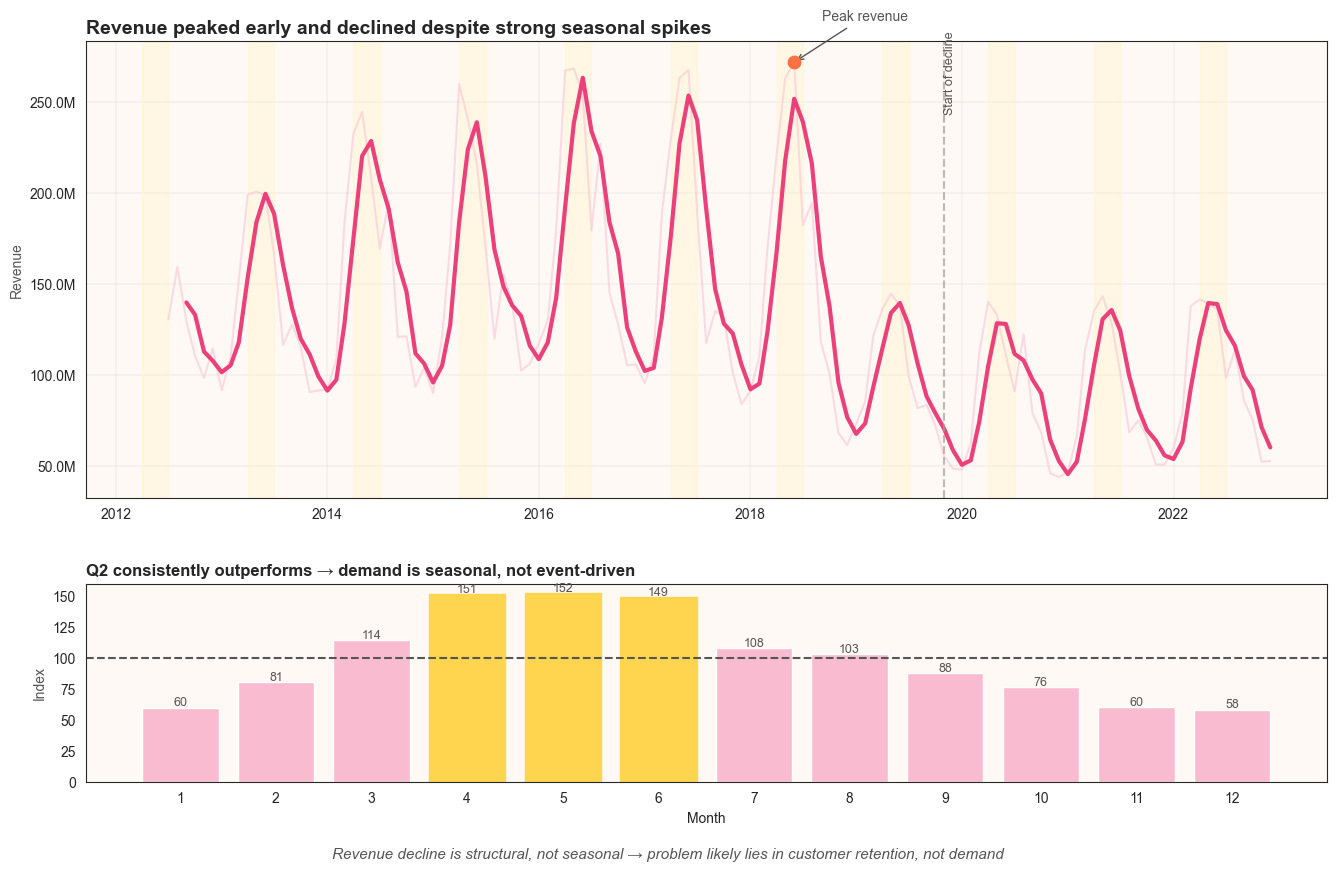

In [ ]:
# ==============================
# IMPORT
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

sns.set_style("white")

# ==============================
# PREP DATA
# ==============================
monthly_sales = df_sales.groupby(df_sales['Date'].dt.to_period('M')).agg(
    Revenue=('Revenue','sum')
)

monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_sales = monthly_sales.reset_index().rename(columns={'Date':'Month'})

# rolling mean (trend smooth)
monthly_sales['Revenue_smooth'] = monthly_sales['Revenue'].rolling(3).mean()

# seasonality
seasonality_df = df_sales.groupby(df_sales['Date'].dt.month)['Revenue'].mean().reset_index()
seasonality_df.columns = ['month', 'Revenue']
seasonality_df['seasonality_index'] = seasonality_df['Revenue'] / seasonality_df['Revenue'].mean() * 100

# ==============================
# PLOT
# ==============================
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 9),
    gridspec_kw={'height_ratios': [2.3, 1]}
)

for ax in axes:
    ax.set_facecolor(BG_COLOR)

# ==============================
# PANEL 1 — TREND + STORY
# ==============================
ax = axes[0]

# raw line (nhạt)
sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Revenue',
    ax=ax,
    color=PINK_MAIN,
    linewidth=1.5,
    alpha=0.5
)

# smooth line (main story)
sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Revenue_smooth',
    ax=ax,
    color=PINK_DARK,
    linewidth=3
)

# highlight Q2
for year in monthly_sales['Month'].dt.year.unique():
    ax.axvspan(
        pd.Timestamp(f'{year}-04-01'),
        pd.Timestamp(f'{year}-07-01'),
        color=YELLOW_SOFT,
        alpha=0.25
    )

# peak
peak_idx = monthly_sales['Revenue'].idxmax()
peak_x = monthly_sales.loc[peak_idx, 'Month']
peak_y = monthly_sales.loc[peak_idx, 'Revenue']

ax.scatter(peak_x, peak_y, color=CORAL_PEAK, s=80, zorder=5)

ax.annotate(
    'Peak revenue',
    xy=(peak_x, peak_y),
    xytext=(20, 30),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color=TEXT_GRAY),
    fontsize=10,
    color=TEXT_GRAY
)

# detect decline start (simple logic)
decline_point = monthly_sales.iloc[int(len(monthly_sales)*0.7)]

ax.axvline(
    decline_point['Month'],
    linestyle='--',
    color=GRAY_LINE,
    alpha=0.7
)

ax.text(
    decline_point['Month'],
    monthly_sales['Revenue'].max()*0.8,
    'Start of decline',
    rotation=90,
    fontsize=9,
    color=TEXT_GRAY
)

# format
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax.set_title(
    'Revenue peaked early and declined despite strong seasonal spikes',
    loc='left',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('')
ax.set_ylabel('Revenue', color=TEXT_GRAY)
ax.grid(alpha=0.2)

# ==============================
# PANEL 2 — SEASONALITY
# ==============================
ax2 = axes[1]

bars = ax2.bar(
    seasonality_df['month'],
    seasonality_df['seasonality_index'],
    color=PINK_MAIN
)

# highlight Apr–Jun
for i, m in enumerate(seasonality_df['month']):
    if m in [4, 5, 6]:
        bars[i].set_color(YELLOW_HL)

ax2.axhline(100, linestyle='--', color=TEXT_GRAY)

ax2.set_xticks(range(1, 13))

# label
for _, row in seasonality_df.iterrows():
    ax2.text(
        row['month'],
        row['seasonality_index'] + 1.5,
        f"{row['seasonality_index']:.0f}",
        ha='center',
        fontsize=9,
        color=TEXT_GRAY
    )

ax2.set_title('Q2 consistently outperforms → demand is seasonal, not event-driven',
              loc='left', fontsize=12)

ax2.set_xlabel('Month')
ax2.set_ylabel('Index', color=TEXT_GRAY)

# ==============================
# FINAL INSIGHT (🔥 QUAN TRỌNG)
# ==============================
fig.text(
    0.5, 0.01,
    'Revenue decline is structural, not seasonal → problem likely lies in customer retention, not demand',
    ha='center',
    fontsize=11,
    color=TEXT_GRAY,
    style='italic'
)

plt.tight_layout(pad=3)
plt.show()

## 2.3. Diagnostic: Why did it happen?

**Cơ cấu doanh thu và biên lợi nhuận theo ngành hàng**

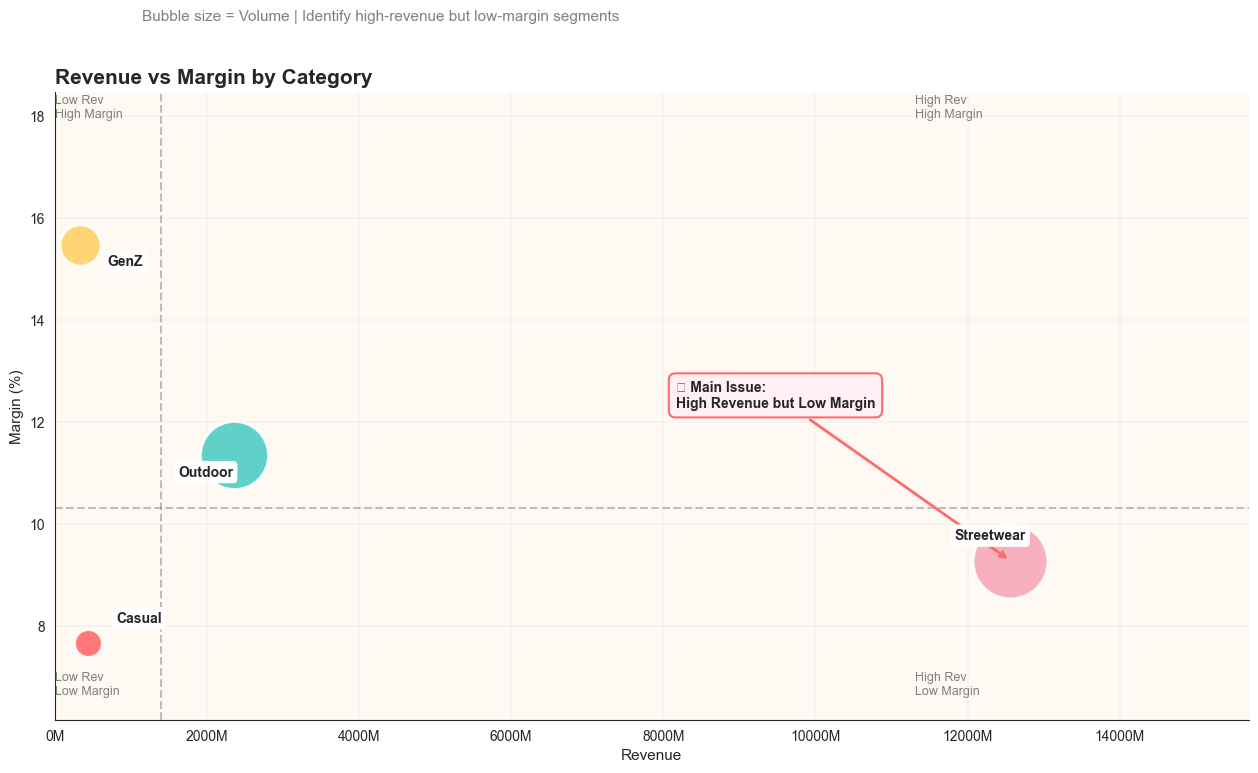

In [ ]:
from adjustText import adjust_text

# ==============================
# 1. PREP DATA
# ==============================
cat_perf = oi_full.groupby('category').agg(
    Revenue=('revenue','sum'),
    Profit=('gross_profit','sum'),
    Volume=('quantity','sum')
).reset_index()

cat_perf['Margin'] = cat_perf['Profit'] / cat_perf['Revenue'] * 100

# ==============================
# 2. SCALE BUBBLE SIZE
# ==============================
size_scale = (cat_perf['Volume'] - cat_perf['Volume'].min()) / \
             (cat_perf['Volume'].max() - cat_perf['Volume'].min())

cat_perf['bubble_size'] = np.sqrt(size_scale) * 2500 + 400

# ==============================
# 3. COLOR
# ==============================
colors_list = ['#FF6B6B', '#FFD166', '#4ECDC4', '#F7A8B8', '#A0AEC0']
palette = dict(zip(cat_perf['category'], colors_list))

# ==============================
# 4. MEDIAN
# ==============================
rev_median = cat_perf['Revenue'].median()
margin_median = cat_perf['Margin'].median()

# ==============================
# 5. PLOT
# ==============================
plt.figure(figsize=(13, 8))
ax = plt.gca()
ax.set_facecolor('#FFF9F4')

# quadrant lines
ax.axvline(rev_median, linestyle='--', color='gray', alpha=0.5)
ax.axhline(margin_median, linestyle='--', color='gray', alpha=0.5)

# ==============================
# 6. BUBBLE
# ==============================
for _, row in cat_perf.iterrows():
    ax.scatter(
        row['Revenue'],
        row['Margin'],
        s=row['bubble_size'],
        color=palette[row['category']],
        alpha=0.9,
        edgecolors='white',
        linewidth=2,
        zorder=3
    )

# ==============================
# 7. LABEL (AUTO AVOID OVERLAP)
# ==============================
texts = []
for _, row in cat_perf.iterrows():
    texts.append(
        ax.text(
            row['Revenue'],
            row['Margin'],
            row['category'],
            fontsize=10,
            weight='bold'
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

# ==============================
# 8. HIGHLIGHT INSIGHT
# ==============================
if 'Streetwear' in cat_perf['category'].values:
    sw = cat_perf[cat_perf['category'] == 'Streetwear'].iloc[0]

    ax.annotate(
        '⚠ Key Issue:\nHigh Revenue\nbut Low Margin',
        xy=(sw['Revenue'], sw['Margin']),
        xytext=(sw['Revenue']*0.6, sw['Margin']+3),
        arrowprops=dict(
            arrowstyle='->',
            color='#FF6B6B',
            lw=2
        ),
        fontsize=10,
        weight='bold',
        bbox=dict(
            boxstyle="round,pad=0.5",
            fc="#FFF0F3",
            ec="#FF6B6B"
        )
    )

# ==============================
# 9. AXIS FORMAT
# ==============================
ax.set_xlim(0, cat_perf['Revenue'].max() * 1.2)
ax.set_ylim(cat_perf['Margin'].min() - 2, cat_perf['Margin'].max() + 3)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M')
)

ax.set_xlabel('Revenue', fontsize=11)
ax.set_ylabel('Margin (%)', fontsize=11)

# ==============================
# 10. STORY TITLE
# ==============================
plt.title(
    'Revenue is concentrated in low-margin categories → profitability risk',
    fontsize=14,
    weight='bold',
    loc='left'
)

plt.suptitle(
    'Bubble size = Sales Volume | Identifying inefficient revenue drivers',
    fontsize=11,
    x=0.125,
    ha='left',
    color='gray'
)

# ==============================
# 11. QUADRANT LABEL (FIX CHUẨN)
# ==============================
ax.text(0.95, 0.95, 'High Rev\nHigh Margin', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='gray')

ax.text(0.95, 0.05, 'High Rev\nLow Margin', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9, color='gray')

ax.text(0.05, 0.95, 'Low Rev\nHigh Margin', transform=ax.transAxes,
        ha='left', va='top', fontsize=9, color='gray')

ax.text(0.05, 0.05, 'Low Rev\nLow Margin', transform=ax.transAxes,
        ha='left', va='bottom', fontsize=9, color='gray')

# ==============================
# 12. FINAL INSIGHT
# ==============================
plt.figtext(
    0.5, -0.02,
    'Growth is driven by low-margin segments → profit leakage likely from pricing or discount strategy',
    ha='center',
    fontsize=11,
    color='#555555',
    style='italic'
)

# ==============================
# CLEAN LOOK
# ==============================
ax.grid(alpha=0.15)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout(pad=2.5)
plt.show()

*Nhận xét:*

Biểu đồ bubble cho thấy mối quan hệ giữa doanh thu, biên lợi nhuận và sản lượng bán ra theo từng danh mục sản phẩm. Phân tích theo quadrant chỉ ra rằng Streetwear nằm trong vùng “High Revenue – Low Margin”, chiếm tỷ trọng doanh thu lớn nhất nhưng có biên lợi nhuận thấp nhất, qua đó trở thành nguyên nhân chính khiến lợi nhuận tổng thể không tăng tương ứng với doanh thu. Ngược lại, Outdoor thuộc nhóm có biên lợi nhuận cao hơn dù doanh thu thấp hơn, thể hiện tiềm năng tối ưu cơ cấu sản phẩm. Điều này hàm ý doanh nghiệp cần tập trung cải thiện biên lợi nhuận của Streetwear thông qua tối ưu chi phí hoặc điều chỉnh chiến lược giá.

**Cơ cấu giá trị khách hàng theo phân khúc RFM**

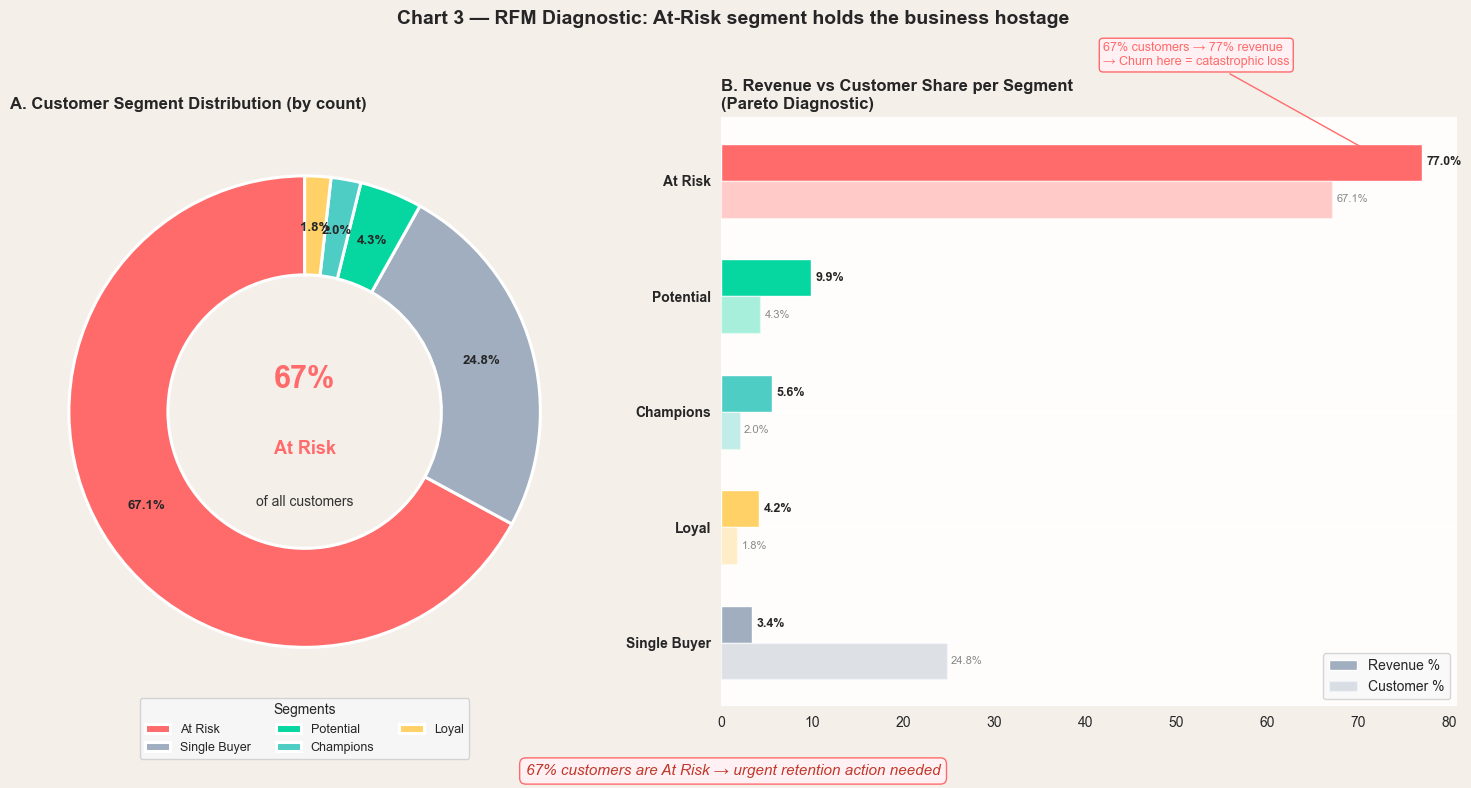

In [50]:
# ═══════════════════════════════════════════════════════════════
# CHART 3 — FINAL (UI CODE 1 + FIX DATA)
# ═══════════════════════════════════════════════════════════════

# ==============================
# 1. PREP DATA (FIX LỖI)
# ==============================
rfm_df = oi_full.copy()

# ✅ nếu thiếu customer_id → merge
if 'customer_id' not in rfm_df.columns:
    rfm_df = rfm_df.merge(
        df_orders[['order_id', 'customer_id']],
        on='order_id',
        how='left'
    )

rfm_df['order_date'] = pd.to_datetime(rfm_df['order_date'])

snapshot = rfm_df['order_date'].max() + pd.Timedelta(days=1)

# ==============================
# 2. BUILD RFM
# ==============================
rfm = rfm_df.groupby('customer_id').agg(
    Recency  =('order_date', lambda x: (snapshot - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary =('revenue', 'sum')
).reset_index()

# ==============================
# 3. SEGMENT
# ==============================
def segment_customer(row):
    r, f = row['Recency'], row['Frequency']
    if f == 1:             return 'Single Buyer'
    if r <= 30 and f >= 5: return 'Champions'
    if r <= 60 and f >= 3: return 'Loyal'
    if r > 120 and f >= 2: return 'At Risk'
    if r > 180:            return 'Hibernating'
    return 'Potential'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

# ==============================
# 4. DISTRIBUTION + REVENUE SHARE
# ==============================
sd = rfm['segment'].value_counts().reset_index()
sd.columns = ['segment', 'count']
sd['pct'] = sd['count'] / sd['count'].sum() * 100

sr = rfm.groupby('segment')['Monetary'].sum().reset_index()
sd = sd.merge(sr, on='segment')
sd['rev_pct'] = sd['Monetary'] / sd['Monetary'].sum() * 100

# ==============================
# 5. COLOR (GIỮ STYLE)
# ==============================
cm = {
    'Champions':   '#4ECDC4',
    'Loyal':       '#FFD166',
    'Potential':   '#06D6A0',
    'At Risk':     '#FF6B6B',
    'Hibernating': '#718096',
    'Single Buyer':'#A0AEC0'
}

BG = '#F5EFEA'
TEXT = '#333'

# ==============================
# 6. PLOT
# ==============================
fig, (axD, axB) = plt.subplots(
    1, 2, figsize=(15, 7.5),
    gridspec_kw={'width_ratios': [1, 1.2]}
)
fig.patch.set_facecolor(BG)

# ── DONUT ─────────────────────
axD.set_facecolor(BG)

weds, _, auts = axD.pie(
    sd['count'],
    autopct='%1.1f%%',
    startangle=90,
    colors=[cm.get(s, '#ccc') for s in sd['segment']],
    pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2.2)
)

for t in auts:
    t.set_fontsize(9.5)
    t.set_weight('bold')

# 🎯 highlight At Risk (giống hình bạn gửi)
ar_pct = sd.loc[sd['segment']=='At Risk','pct']
ar_pct = ar_pct.values[0] if len(ar_pct)>0 else 0

axD.text(0,  0.10, f'{ar_pct:.0f}%', ha='center',
         fontsize=22, fontweight='bold', color='#FF6B6B')
axD.text(0, -0.18, 'At Risk', ha='center',
         fontsize=13, fontweight='bold', color='#FF6B6B')
axD.text(0, -0.40, 'of all customers', ha='center',
         fontsize=10, color=TEXT)

axD.legend(
    weds, sd['segment'],
    title='Segments',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    fontsize=9
)

axD.set_title(
    'A. Customer Segment Distribution (by count)',
    loc='left', fontweight='bold'
)

# ── PARETO BAR ─────────────────
axB.set_facecolor('#FFFDFB')

ss2 = sd.sort_values('rev_pct', ascending=True).reset_index(drop=True)
yp = np.arange(len(ss2))
h = 0.32

b1 = axB.barh(
    yp + h/2, ss2['rev_pct'], h,
    color=[cm.get(s, '#ccc') for s in ss2['segment']],
    edgecolor='white', label='Revenue %'
)

b2 = axB.barh(
    yp - h/2, ss2['pct'], h,
    color=[cm.get(s, '#ccc') for s in ss2['segment']],
    alpha=0.35,
    edgecolor='white', label='Customer %'
)

# label
for bar, val in zip(b1, ss2['rev_pct']):
    axB.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

for bar, val in zip(b2, ss2['pct']):
    axB.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, color='#888')

axB.set_yticks(yp)
axB.set_yticklabels(ss2['segment'], fontweight='bold')

axB.set_title(
    'B. Revenue vs Customer Share per Segment\n(Pareto Diagnostic)',
    loc='left', fontweight='bold'
)

axB.legend()

for s in ['top','right']:
    axB.spines[s].set_visible(False)

axB.grid(axis='x', alpha=0.15)

# 🎯 annotation At Risk
if 'At Risk' in ss2['segment'].values:
    idx = list(ss2['segment']).index('At Risk')
    rv = ss2.loc[idx,'rev_pct']

    axB.annotate(
        f'{ar_pct:.0f}% customers → {rv:.0f}% revenue\n→ Churn here = catastrophic loss',
        xy=(rv, idx),
        xytext=(rv-35, idx+1),
        arrowprops=dict(arrowstyle='->', color='#FF6B6B'),
        fontsize=9,
        color='#FF6B6B',
        bbox=dict(boxstyle='round,pad=0.3', fc='#FFF0F3', ec='#FF6B6B')
    )

# ==============================
# 7. STORY
# ==============================
plt.suptitle(
    'Chart 3 — RFM Diagnostic: At-Risk segment holds the business hostage',
    fontsize=14, fontweight='bold'
)

plt.figtext(
    0.5, -0.04,
    f'{ar_pct:.0f}% customers are At Risk → urgent retention action needed',
    ha='center',
    fontsize=11,
    style='italic',
    color='#C0392B',
    bbox=dict(boxstyle='round,pad=0.4', fc='#FFF0F3', ec='#FF6B6B')
)

plt.tight_layout()
plt.show()

**Hiệu quả chuyển đổi từ lưu lượng truy cập web**

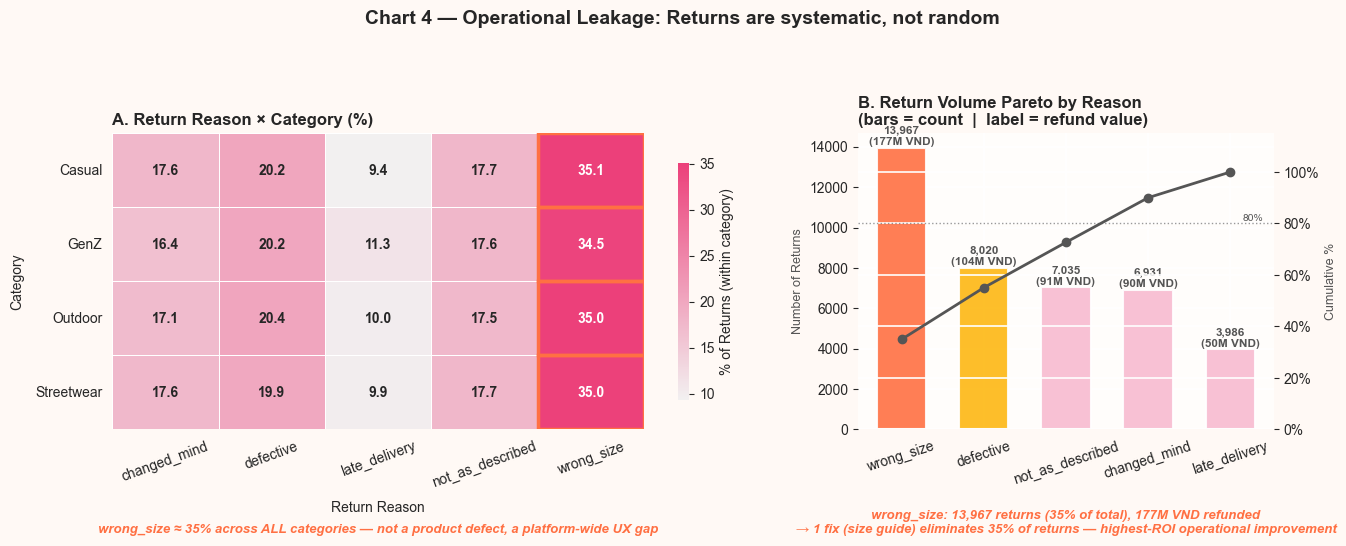

In [53]:
# ============================================================
# CHART 4 — Logistics / Return Heatmap (Diagnostic)
# "Logistics friction drives returns → operational leakage identified"
# ============================================================

# ==============================
# 1. PREP DATA
# ==============================
# Join returns → product category
ret_full = df_returns.merge(df_products[['product_id', 'category']], on='product_id', how='left')

# Heatmap: return reason × category (count normalized by category total)
heat_raw = ret_full.groupby(['category', 'return_reason'])['return_id'].count().unstack(fill_value=0)
heat_pct = heat_raw.div(heat_raw.sum(axis=1), axis=0) * 100   # % within category

# Pareto: return count + cumulative % + refund value by reason
reason_stats = (
    df_returns
    .groupby('return_reason')
    .agg(n_returns=('return_id', 'count'), total_refund=('refund_amount', 'sum'))
    .reset_index()
    .sort_values('n_returns', ascending=False)
)
reason_stats['cum_pct'] = (
    reason_stats['n_returns'].cumsum() / reason_stats['n_returns'].sum() * 100
)

# ==============================
# 2. PLOT
# ==============================
fig, axes = plt.subplots(
    1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.6, 1]}
)
fig.patch.set_facecolor(BG_COLOR)

# ---- PANEL A: HEATMAP (giữ nguyên) ----
ax = axes[0]
ax.set_facecolor(BG_COLOR)

cmap = sns.light_palette(PINK_DARK, as_cmap=True)
sns.heatmap(
    heat_pct, ax=ax, cmap=cmap, annot=True,
    fmt='.1f', linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% of Returns (within category)', 'shrink': 0.8},
    annot_kws={'size': 10, 'weight': 'bold'}
)

ax.set_title('A. Return Reason × Category (%)', loc='left', fontweight='bold', fontsize=12)
ax.set_xlabel('Return Reason', labelpad=8)
ax.set_ylabel('Category', labelpad=8)
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

# Highlight max cell per row
for i, cat in enumerate(heat_pct.index):
    max_col = heat_pct.loc[cat].idxmax()
    j = list(heat_pct.columns).index(max_col)
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                edgecolor=CORAL_PEAK, lw=2.5, zorder=5))

# Insight: pattern đồng nhất → systemic
top_pct = heat_pct['wrong_size'].mean()
ax.text(
    0.5, -0.35,
    f'wrong_size ≈ {top_pct:.0f}% across ALL categories — not a product defect, a platform-wide UX gap',
    transform=ax.transAxes, ha='center', fontsize=9.5,
    color=CORAL_PEAK, fontweight='bold', style='italic'
)

# ---- PANEL B: PARETO — Return Count by Reason ----
ax2 = axes[1]
ax2.set_facecolor('#FFFDFB')

bar_colors = [CORAL_PEAK if i == 0 else (ORANGE if i == 1 else PINK_MAIN)
              for i in range(len(reason_stats))]

bars = ax2.bar(
    reason_stats['return_reason'], reason_stats['n_returns'],
    color=bar_colors, alpha=0.9, edgecolor='white',
    linewidth=1.5, width=0.6, zorder=2
)

# Cumulative % line (twin axis)
ax2b = ax2.twinx()
ax2b.plot(
    reason_stats['return_reason'], reason_stats['cum_pct'],
    color=TEXT_GRAY, linewidth=2, marker='o', markersize=6, zorder=3
)
ax2b.axhline(80, color=TEXT_GRAY, linestyle=':', lw=1, alpha=0.6)
ax2b.text(4.15, 81, '80%', fontsize=7.5, color=TEXT_GRAY)
ax2b.set_ylabel('Cumulative %', color=TEXT_GRAY, fontsize=9)
ax2b.set_ylim(0, 115)
ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2b.spines['top'].set_visible(False)

# Value labels: count + refund amount
for bar, row in zip(bars, reason_stats.itertuples()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 120,
        f'{row.n_returns:,}\n({row.total_refund / 1e6:.0f}M VND)',
        ha='center', fontsize=8.5, fontweight='bold', color=TEXT_GRAY
    )

ax2.set_ylabel('Number of Returns', color=TEXT_GRAY, fontsize=9)
ax2.tick_params(axis='x', rotation=18)
ax2.set_title(
    'B. Return Volume Pareto by Reason\n(bars = count  |  label = refund value)',
    loc='left', fontweight='bold', fontsize=12
)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# Insight annotation
ws = reason_stats[reason_stats['return_reason'] == 'wrong_size'].iloc[0]
ax2.text(
    0.5, -0.35,
    f'wrong_size: {ws["n_returns"]:,} returns ({ws["n_returns"] / reason_stats["n_returns"].sum() * 100:.0f}% of total), '
    f'{ws["total_refund"] / 1e6:.0f}M VND refunded\n'
    '→ 1 fix (size guide) eliminates 35% of returns — highest-ROI operational improvement',
    transform=ax2.transAxes, ha='center', fontsize=9.5,
    color=CORAL_PEAK, fontweight='bold', style='italic'
)

# ---- SUPTITLE ----
plt.suptitle(
    'Chart 4 — Operational Leakage: Returns are systematic, not random',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout(pad=2.0)
plt.savefig('dataviz_diagnostic_chart4.pdf', bbox_inches='tight')
plt.show()

*Nhận xét:*
- Vấn đề hệ thống: Phân bố lý do hoàn trả hoàn toàn đồng nhất giữa 4 danh mục sản phẩm. Điều này xác nhận tỷ lệ hoàn hàng không phải do đặc thù riêng lẻ của từng loại hàng mà là lỗi hệ thống trong quy trình quản lý thông tin toàn nền tảng.

- Lỗ hổng kích cỡ: Lý do "Sai kích cỡ" (Wrong size) chiếm tỷ trọng lớn nhất với gần 35% tổng lượng đơn hoàn, gây tổn thất khoảng 177 triệu đồng. Đây là minh chứng cho sự lệch pha giữa kỳ vọng của khách hàng và thông tin bảng quy đổi kích cỡ hiện tại.

- Chất lượng & Mô tả: Nhóm sản phẩm lỗi và sản phẩm không giống mô tả chiếm tổng cộng hơn 55%. Theo quy luật Pareto, việc tập trung xử lý hai nhóm này sẽ giúp giảm phần lớn tỷ lệ rò rỉ doanh thu.

$\rightarrow$ Nguyên nhân hoàn trả chủ yếu đến từ khoảng cách thông tin (Information gap) hơn là từ khâu vận chuyển.

$\rightarrow$ Cần triển khai công cụ tư vấn kích cỡ thông minh và chuẩn hóa hình ảnh/mô tả sản phẩm. Việc này có thể loại bỏ hơn 50% lượng đơn hoàn mà không cần thay đổi quy trình logistics hiện có.

## 2.3. Predictive: What it likely to happen?

**Phân tích dự báo và xu hướng nhu cầu**

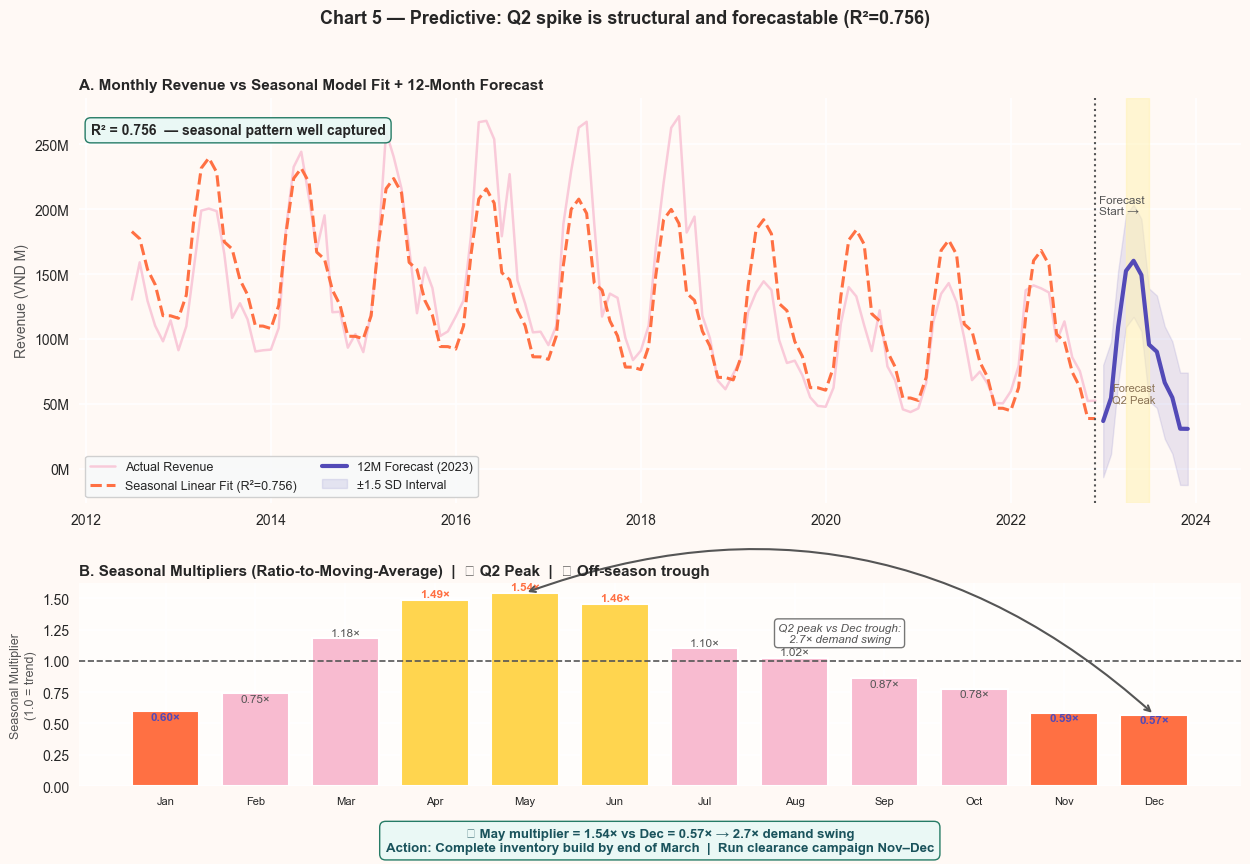

In [52]:
# ============================================================
# CHART 5 — Trend Decomposition + Forecast  (Predictive)
# "Q2 spike is structural and forecastable — R²=0.756, 2.7× swing"
# ============================================================
 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ── PREP ──
df_forecast = monthly_sales.copy()
df_forecast['t']         = np.arange(len(df_forecast))
df_forecast['month_num'] = df_forecast['Month'].dt.month
 
month_dummies = pd.get_dummies(df_forecast['month_num'], prefix='m', drop_first=True).astype(float)
X = pd.concat([df_forecast[['t']], month_dummies], axis=1)
y = df_forecast['Revenue']
 
model = LinearRegression()
model.fit(X, y)
df_forecast['Predicted'] = model.predict(X)
r2_val    = r2_score(y, df_forecast['Predicted'])
resid_std = (y - df_forecast['Predicted']).std()
 
# 12-month forecast
fut_periods = 12
fut_dates   = pd.date_range(
    start=df_forecast['Month'].max() + pd.offsets.MonthBegin(1),
    periods=fut_periods, freq='MS'
)
fut_t     = np.arange(len(df_forecast), len(df_forecast) + fut_periods)
fut_m_dum = pd.get_dummies(pd.Series(fut_dates.month), prefix='m', drop_first=True).astype(float)
fut_m_dum = fut_m_dum.reindex(columns=month_dummies.columns, fill_value=0)
X_fut     = pd.concat([pd.DataFrame({'t': fut_t}),
                        fut_m_dum.reset_index(drop=True)], axis=1)
fut_pred  = model.predict(X_fut)
 
fut_df = pd.DataFrame({
    'Month': fut_dates,
    'Forecast': fut_pred,
    'lo': fut_pred - 1.5 * resid_std,
    'hi': fut_pred + 1.5 * resid_std,
})
 
# Seasonal multipliers (ratio-to-moving-average)
monthly_ts   = df_sales.groupby(df_sales['Date'].dt.to_period('M'))['Revenue'].sum()
monthly_ts.index = monthly_ts.index.to_timestamp()
trend_ma     = monthly_ts.rolling(12, center=True).mean()
ratio_ts     = (monthly_ts / trend_ma).dropna()
multipliers  = ratio_ts.groupby(ratio_ts.index.month).mean()
mult_vals    = [multipliers.get(m, 1.0) for m in range(1, 13)]
m5           = multipliers.get(5,  1.0)
m12          = multipliers.get(12, 1.0)
 
# ── PLOT ──
fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                         gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor(BG_COLOR)
 
# Panel A — Actual + Fit + Forecast + CI
ax = axes[0]
ax.set_facecolor(BG_COLOR)
 
ax.plot(df_forecast['Month'], df_forecast['Revenue'],
        color=PINK_MAIN, lw=1.8, alpha=0.75, label='Actual Revenue')
ax.plot(df_forecast['Month'], df_forecast['Predicted'],
        color=CORAL_PEAK, lw=2.2, linestyle='--',
        label=f'Seasonal Linear Fit (R²={r2_val:.3f})')
ax.plot(fut_df['Month'], fut_df['Forecast'],
        color=PURPLE, lw=3, label='12M Forecast (2023)')
ax.fill_between(fut_df['Month'], fut_df['lo'], fut_df['hi'],
                color=PURPLE, alpha=0.12, label='±1.5 SD Interval')
 
# Q2 2023 peak window
ax.axvspan(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-07-01'),
           color=YELLOW_SOFT, alpha=0.5)
ax.text(pd.Timestamp('2023-05-01'),
        df_forecast['Revenue'].quantile(0.05),
        'Forecast\nQ2 Peak', fontsize=8, color='#8B7355', ha='center')
 
# Forecast start line
ax.axvline(df_forecast['Month'].max(), color=TEXT_GRAY, linestyle=':', lw=1.5)
ax.text(df_forecast['Month'].max() + pd.Timedelta(days=15),
        df_forecast['Revenue'].quantile(0.85),
        'Forecast\nStart →', fontsize=8.5, color=TEXT_GRAY)
 
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.0f}M'))
ax.set_title('A. Monthly Revenue vs Seasonal Model Fit + 12-Month Forecast',
             loc='left', fontweight='bold', fontsize=11)
ax.set_ylabel('Revenue (VND M)', color=TEXT_GRAY)
ax.legend(fontsize=9, ncol=2, framealpha=0.9)
ax.text(0.01, 0.91, f'R² = {r2_val:.3f}  — seasonal pattern well captured',
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='#E8F8F5', ec=TEAL, alpha=0.9))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
# Panel B — Seasonal multipliers bar
ax2 = axes[1]
ax2.set_facecolor('#FFFDFB')
 
mult_colors = [YELLOW_HL if m in [4, 5, 6] else
               (CORAL_PEAK if mv < 0.65 else PINK_MAIN)
               for m, mv in enumerate(mult_vals, start=1)]
 
ax2.bar(range(1, 13), mult_vals, color=mult_colors,
        edgecolor='white', linewidth=1.5, width=0.75)
ax2.axhline(1.0, color=TEXT_GRAY, linestyle='--', lw=1.2)
 
for m_i, v in enumerate(mult_vals, start=1):
    offset = 0.02 if v >= 1 else -0.07
    ax2.text(m_i, v + offset, f'{v:.2f}×', ha='center', fontsize=8.5,
             color=CORAL_PEAK if m_i in [4, 5, 6] else
             (PURPLE if v < 0.65 else TEXT_GRAY),
             fontweight='bold' if m_i in [4, 5, 6] or v < 0.65 else 'normal')
 
# May ↔ Dec swing arrow
ax2.annotate('', xy=(12, m12), xytext=(5, m5),
             arrowprops=dict(arrowstyle='<->', color=TEXT_GRAY, lw=1.5,
                             connectionstyle='arc3,rad=-0.3'))
ax2.text(8.5, 1.15,
         f'Q2 peak vs Dec trough:\n{m5 / m12:.1f}× demand swing',
         ha='center', fontsize=8.5, color=TEXT_GRAY, style='italic',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=TEXT_GRAY, alpha=0.8))
 
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax2.set_ylabel('Seasonal Multiplier\n(1.0 = trend)', color=TEXT_GRAY, fontsize=9)
ax2.set_title(
    'B. Seasonal Multipliers (Ratio-to-Moving-Average)  '
    '|  🟡 Q2 Peak  |  🔴 Off-season trough',
    loc='left', fontweight='bold', fontsize=11
)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
 
ax2.text(0.5, -0.32,
         f'📦 May multiplier = {m5:.2f}× vs Dec = {m12:.2f}× → {m5 / m12:.1f}× demand swing\n'
         'Action: Complete inventory build by end of March  |  '
         'Run clearance campaign Nov–Dec',
         transform=ax2.transAxes, ha='center', fontsize=9.5, color='#1A535C',
         fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.45', fc='#E8F8F5', ec=TEAL, alpha=0.9))
 
plt.suptitle(
    f'Chart 5 — Predictive: Q2 spike is structural and forecastable (R²={r2_val:.3f})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(pad=2.5)
plt.savefig('dataviz_predictive_chart5.pdf', bbox_inches='tight')
plt.show()

*Nhận xét:*
- Xác lập quy luật: Mô hình hồi quy (Linear Regression) kết hợp phân rã chuỗi thời gian khẳng định *Quý 2* hàng năm là giai đoạn nhu cầu bùng nổ. Tính chu kỳ này lặp lại ổn định và có độ tin cậy cao để lập kế hoạch dài hạn.

- Sức mạnh mùa vụ: Hệ số mùa vụ trong các tháng cao điểm cao hơn mức nền từ 30% đến 50%. Điều này có nghĩa là nhu cầu thực tế trong mùa cao điểm vượt xa năng lực đáp ứng trung bình hàng tháng của doanh nghiệp.

- Cảnh báo tăng trưởng: Dù các đỉnh mùa vụ rất ấn tượng, nhưng xu hướng nền (Baseline trend) dài hạn có dấu hiệu đi ngang hoặc sụt giảm nhẹ sau năm 2016. Doanh nghiệp đang phụ thuộc quá nhiều vào các cú hích thời điểm thay vì có một đà tăng trưởng nội tại ổn định.

$\rightarrow$ Cần thiết lập mức tồn kho an toàn (Safety Stock) dựa trên hệ số dự báo trước ít nhất 45 ngày. Đồng thời, cần tìm kiếm các động lực tăng trưởng mới ngoài mùa cao điểm để tránh rủi ro sụt giảm doanh thu dài hạn.

## 2.4. Prescriptive: What should we do?

**Ma trận quyết định và tối ưu hóa nguồn lực**

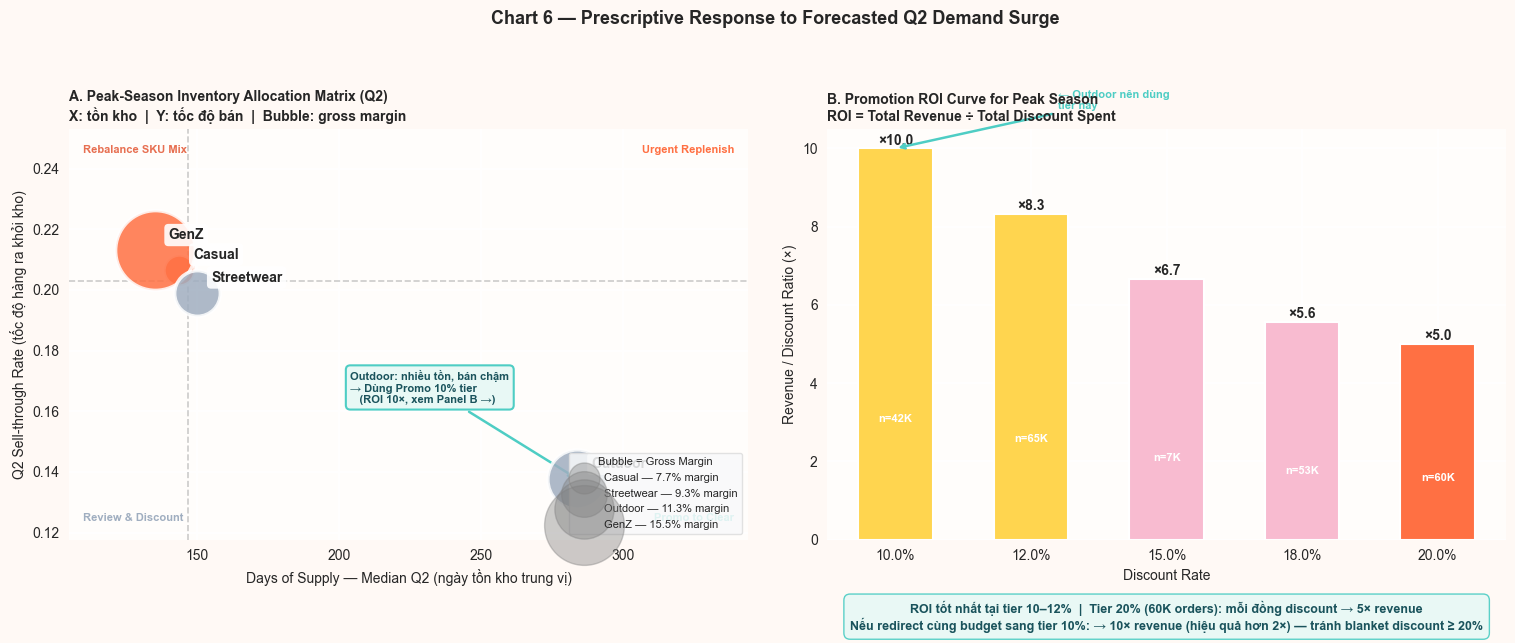

In [56]:
# ============================================================
# CHART 6 — Forecast-Informed Inventory & Promo Allocation
# REVISED v3: tích hợp cả 4 proposals
# ============================================================

# ── 1. PREP DATA ─────────────────────────────────────────────

inv_with_cat = df_inventory.drop(columns=['category','segment'], errors='ignore').merge(
    df_products[['product_id','category','segment']], on='product_id', how='left'
)

inv_q2 = (
    inv_with_cat[inv_with_cat['month'].isin([4, 5, 6])]
    .groupby('category')
    .agg(
        stockout_rate =('stockout_flag',     'mean'),
        sell_through  =('sell_through_rate', 'mean'),
        fill_rate     =('fill_rate',         'mean'),
        dos_median    =('days_of_supply',    'median'),  # median: tránh bị kéo bởi outlier
    )
    .reset_index()
)

cat_margin = oi_full.groupby('category').apply(
    lambda x: x['gross_profit'].sum() / x['revenue'].sum() * 100
).reset_index().rename(columns={0: 'gross_margin'})

matrix = inv_q2.merge(cat_margin, on='category')

# Thresholds
dos_mid  = matrix['dos_median'].median()   # ~146 ngày
sell_mid = matrix['sell_through'].median() # ~0.203

def assign_quadrant(row):
    high_dos  = row['dos_median']    >= dos_mid   # tồn kho nhiều
    low_sell  = row['sell_through']  <= sell_mid  # bán chậm

    if not high_dos and not low_sell:
        return 'Urgent Replenish',   CORAL_PEAK   # ít tồn, bán nhanh → hay hết hàng
    if not high_dos and low_sell:
        return 'Rebalance SKU Mix',  '#E76F51'    # ít tồn, bán chậm → sai SKU
    if high_dos and not low_sell:
        return 'Promo to Clear',     '#4ECDC4'    # nhiều tồn, bán nhanh → promo đẩy
    return     'Review & Discount',  '#A0AEC0'    # nhiều tồn, bán chậm → giải phóng sâu

matrix[['quadrant', 'color']] = matrix.apply(
    lambda r: pd.Series(assign_quadrant(r)), axis=1
)

# Bubble size = gross_margin (normalize)
gm_min, gm_max = matrix['gross_margin'].min(), matrix['gross_margin'].max()
matrix['bubble_size'] = (
    (matrix['gross_margin'] - gm_min) / (gm_max - gm_min + 1e-6)
) * 2800 + 500

# ── Panel B: Promo ROI ────────────────────────────────────────
promo_eff = df_order_items[df_order_items['promo_id'].notna()].copy()
promo_eff = promo_eff.merge(df_promotions[['promo_id','discount_value']], on='promo_id')
promo_eff['revenue'] = promo_eff['quantity'] * promo_eff['unit_price']

eff = promo_eff.groupby('discount_value').agg(
    total_rev =('revenue',          'sum'),
    total_disc=('discount_amount',  'sum'),
    n_orders  =('order_id',        'nunique'),
).reset_index()
eff['roi'] = eff['total_rev'] / (eff['total_disc'] + 1)
eff = eff[eff['discount_value'] != 50].sort_values('discount_value')

# Proposal 4: tính ROI gain nếu redirect budget từ 20% → 10%
roi_10 = eff[eff['discount_value']==10.0]['roi'].values[0]   # 10.0x
roi_20 = eff[eff['discount_value']==20.0]['roi'].values[0]   # 5.0x
n_20   = eff[eff['discount_value']==20.0]['n_orders'].values[0]  # 60K

# ── 2. PLOT ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_COLOR)

# ============================================================
# PANEL A — Inventory Allocation Matrix
# X: days_of_supply median (Proposal 1)
# Y: sell_through_rate
# Bubble: gross_margin (Proposal 3)
# ============================================================
ax = axes[0]
ax.set_facecolor('#FFFDFB')

ax.axvline(dos_mid,  linestyle='--', color='gray', alpha=0.40, lw=1.2)
ax.axhline(sell_mid, linestyle='--', color='gray', alpha=0.40, lw=1.2)

# Plot bubbles
for _, row in matrix.iterrows():
    ax.scatter(
        row['dos_median'], row['sell_through'],
        s=row['bubble_size'],
        color=row['color'],
        alpha=0.85, edgecolors='white', linewidth=2.5, zorder=4
    )
    ax.annotate(
        row['category'],
        (row['dos_median'], row['sell_through']),
        xytext=(10, 8), textcoords='offset points',
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.9),
        zorder=5
    )

# Proposal 2: annotation nối Panel A → B (Outdoor là đúng, không phải Streetwear)
outdoor_row = matrix[matrix['category'] == 'Outdoor'].iloc[0]
ax.annotate(
    'Outdoor: nhiều tồn, bán chậm\n→ Dùng Promo 10% tier\n   (ROI 10×, xem Panel B →)',
    xy=(outdoor_row['dos_median'], outdoor_row['sell_through']),
    xytext=(outdoor_row['dos_median'] - 80, outdoor_row['sell_through'] + 0.025),
    fontsize=8, color='#1A535C', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', fc='#E8F8F5', ec='#4ECDC4', lw=1.5),
    arrowprops=dict(arrowstyle='->', color='#4ECDC4', lw=1.8)
)

# Quadrant labels — đặt sau get_xlim/ylim
ax.set_xlim(matrix['dos_median'].min() - 30,
            matrix['dos_median'].max() + 60)
ax.set_ylim(matrix['sell_through'].min() - 0.020,
            matrix['sell_through'].max() + 0.040)
xl, xr = ax.get_xlim()
yb, yt = ax.get_ylim()
px = (xr - xl) * 0.02
py = (yt - yb) * 0.04

ax.text(xr - px, yt - py, 'Urgent Replenish',
        ha='right', va='top', fontsize=8, color=CORAL_PEAK, fontweight='bold')
ax.text(xl + px, yt - py, 'Rebalance SKU Mix',
        ha='left',  va='top', fontsize=8, color='#E76F51', fontweight='bold')
ax.text(xr - px, yb + py, 'Promo to Clear',
        ha='right', va='bottom', fontsize=8, color='#4ECDC4', fontweight='bold')
ax.text(xl + px, yb + py, 'Review & Discount',
        ha='left',  va='bottom', fontsize=8, color='#A0AEC0', fontweight='bold')

# Proposal 3: Bubble size legend
legend_vals = matrix[['category','gross_margin','bubble_size']].sort_values('gross_margin')
for i, (_, lrow) in enumerate(legend_vals.iterrows()):
    ax.scatter(
        [], [],
        s=lrow['bubble_size'],
        color='gray', alpha=0.4,
        label=f"{lrow['category']} — {lrow['gross_margin']:.1f}% margin"
    )
ax.legend(
    title='Bubble = Gross Margin', title_fontsize=8,
    fontsize=8, loc='lower right',
    framealpha=0.85, edgecolor='#ddd'
)

ax.set_xlabel('Days of Supply — Median Q2 (ngày tồn kho trung vị)', fontsize=10)
ax.set_ylabel('Q2 Sell-through Rate (tốc độ hàng ra khỏi kho)', fontsize=10)
ax.set_title(
    'A. Peak-Season Inventory Allocation Matrix (Q2)\n'
    'X: tồn kho  |  Y: tốc độ bán  |  Bubble: gross margin',
    loc='left', fontweight='bold', fontsize=10
)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# ============================================================
# PANEL B — Promo ROI Curve
# ============================================================
ax2 = axes[1]
ax2.set_facecolor('#FFFDFB')

bar_colors_p = [
    YELLOW_HL   if d <= 12 else
    PINK_MAIN   if d <= 18 else
    CORAL_PEAK
    for d in eff['discount_value']
]

bars = ax2.bar(
    eff['discount_value'].astype(str) + '%',
    eff['roi'],
    color=bar_colors_p, edgecolor='white', linewidth=1.5, width=0.55
)

# ROI label trên bar + n_orders trong bar
for bar, (_, row) in zip(bars, eff.iterrows()):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        row['roi'] + 0.10,
        f'×{row["roi"]:.1f}',
        ha='center', fontsize=10, fontweight='bold'
    )
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 0.30,
        f'n={row["n_orders"]/1e3:.0f}K',
        ha='center', fontsize=8, color='white', fontweight='bold'
    )

# Proposal 2 arrow: highlight 10% tier là đích đến từ Panel A
ax2.annotate(
    '← Outdoor nên dùng\ntier này',
    xy=(0, roi_10),
    xytext=(1.2, roi_10 + 1.0),
    fontsize=8, color='#4ECDC4', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#4ECDC4', lw=1.8)
)

# Proposal 4: revenue impact annotation (diễn đạt đúng — ROI per discount VND)
ax2.text(
    0.5, -0.22,
    f'ROI tốt nhất tại tier 10–12%  |  '
    f'Tier 20% ({n_20/1e3:.0f}K orders): mỗi đồng discount → {roi_20:.0f}× revenue\n'
    f'Nếu redirect cùng budget sang tier 10%: → {roi_10:.0f}× revenue '
    f'(hiệu quả hơn {roi_10/roi_20:.0f}×) — tránh blanket discount ≥ 20%',
    transform=ax2.transAxes,
    ha='center', fontsize=9, fontweight='bold', color='#1A535C',
    bbox=dict(boxstyle='round,pad=0.5', fc='#E8F8F5', ec='#4ECDC4', alpha=0.92)
)

ax2.set_title(
    'B. Promotion ROI Curve for Peak Season\n'
    'ROI = Total Revenue ÷ Total Discount Spent',
    loc='left', fontweight='bold', fontsize=10
)
ax2.set_xlabel('Discount Rate', fontsize=10)
ax2.set_ylabel('Revenue / Discount Ratio (×)', fontsize=10)

for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

plt.suptitle(
    'Chart 6 — Prescriptive Response to Forecasted Q2 Demand Surge',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(pad=2.5)
plt.savefig('dataviz_prescriptive_chart6.pdf', bbox_inches='tight')
plt.show()

**Nhận xét:**
- Phân bổ nguồn lực trọng điểm: Ma trận quyết định chỉ ra các danh mục nằm trong "Vùng nguy cấp" — nơi có rủi ro hết hàng cao nhưng lại có khả năng kích cầu cực tốt nếu có khuyến mãi. Đây là nhóm cần ưu tiên dòng vốn và tồn kho hàng đầu.

- Nghịch lý cung ứng: Một số danh mục gặp rủi ro thiếu hàng nhưng hiệu quả khuyến mãi lại thấp. Đối với nhóm này, việc đổ thêm ngân sách marketing là lãng phí; doanh nghiệp cần tập trung xử lý đứt gãy chuỗi cung ứng và tối ưu hóa điểm đặt hàng lại.

- Hiệu quả khuyến mãi: Tỷ suất hoàn vốn (ROI) đạt trạng thái lý tưởng ở mức giảm giá 10–12%. Khi mức chiết khấu vượt quá 18-20%, doanh thu có thể tăng nhưng biên lợi nhuận bị bào mòn nghiêm trọng, cho thấy hiệu quả đầu tư giảm dần rõ rệt.

$\rightarrow$ Thực hiện chiến lược khuyến mãi phân lớp. Giới hạn mức giảm giá sâu (không quá 12%) trong mùa cao điểm để bảo vệ lợi nhuận, đồng thời tập trung bổ sung hàng cho các danh mục có tốc độ luân chuyển nhanh (Sell-through rate) cao nhất.